In [4]:
import sys
sys.path.insert(0, ".")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import json
import os
import warnings
warnings.filterwarnings("ignore")

from src.models.ml_models import prepare_ml_data, time_series_split
from src.models.tuning import tune_lightgbm, compare_before_after
from src.models.explainability import (
    explain_model,
    plot_shap_summary,
    plot_shap_bar,
    plot_shap_waterfall,
    plot_shap_dependence
)
from src.evaluation.metrics import evaluate_all

print("All imports done!")

All imports done!


In [5]:
df = pd.read_parquet("data/processed/train_features.parquet")

train_df, test_df = time_series_split(df, test_weeks=12)

X_train, y_train = prepare_ml_data(train_df)
X_test,  y_test  = prepare_ml_data(test_df)

print("Data ready!")
print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)

Train: 2010-03-05 → 2012-08-03 (372898 rows)
Test:  2012-08-10 → 2012-10-26 (35538 rows)
Data ready!
X_train shape: (372898, 44)
X_test shape:  (35538, 44)


In [6]:
lgb_model = joblib.load("models/saved/lightgbm.pkl")

# Get its current performance (before tuning)
preds_before  = lgb_model.predict(X_test)
metrics_before = evaluate_all(y_test, preds_before)

print("Phase 5 LightGBM (before tuning):")
print(f"  RMSE  : {metrics_before['RMSE']:.2f}")
print(f"  MAPE  : {metrics_before['MAPE']:.2f}%")
print(f"  R2    : {metrics_before['R2']:.4f}")

Phase 5 LightGBM (before tuning):
  RMSE  : 2734.33
  MAPE  : 1029.99%
  R2    : 0.9844


In [7]:
print("Starting hyperparameter tuning...")
print("Optuna will try 50 different combinations of settings.")
print("Please wait — this takes about 5-10 minutes.\n")

tuned_model, best_params, metrics_after, tuned_preds = tune_lightgbm(
    X_train, y_train,
    X_test,  y_test,
    n_trials=50
)

Starting hyperparameter tuning...
Optuna will try 50 different combinations of settings.
Please wait — this takes about 5-10 minutes.

Starting Optuna tuning — 50 trials...
Each trial trains one model. This may take 5-10 minutes.



  0%|          | 0/50 [00:00<?, ?it/s]


Best settings found:
  n_estimators             : 161
  learning_rate            : 0.0391797244123424
  max_depth                : 10
  num_leaves               : 75
  min_child_samples        : 23
  subsample                : 0.7725399267857372
  colsample_bytree         : 0.7515305347412756
  reg_alpha                : 0.00018669925637060822
  reg_lambda               : 1.5352996391374198

Training final model with best settings...

Tuned LightGBM Results:
  RMSE  : 2551.39
  MAPE  : 1489.60%
  R2    : 0.9864


In [8]:
print("Calculating SHAP values...")
print("This explains why the model makes each prediction.\n")

explainer, shap_values = explain_model(
    tuned_model,
    X_train,
    X_test,
    model_name="LightGBM"
)

print("Done! Now generating explanation plots...")

Calculating SHAP values...
This explains why the model makes each prediction.

Calculating SHAP values for LightGBM...
This may take 1-2 minutes...

SHAP values calculated!
Shape: (35538, 44) (rows x features)

Done! Now generating explanation plots...


Plotting SHAP Summary Plot...


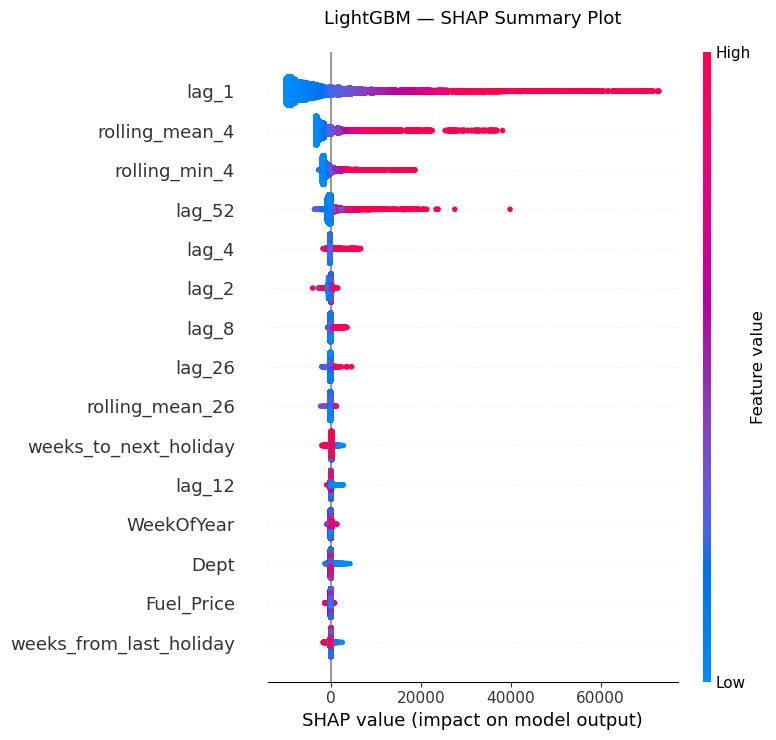

Saved!

How to read this plot:
  - Each row = one feature
  - Red dots = high feature value, Blue = low value
  - Dots on RIGHT = pushed prediction UP
  - Dots on LEFT  = pushed prediction DOWN


In [9]:
plot_shap_summary(shap_values, X_test, model_name="LightGBM")

print("How to read this plot:")
print("  - Each row = one feature")
print("  - Red dots = high feature value, Blue = low value")
print("  - Dots on RIGHT = pushed prediction UP")
print("  - Dots on LEFT  = pushed prediction DOWN")

In [ ]:
plot_shap_bar(shap_values, X_test, model_name="LightGBM")

print("This shows average feature importance across all predictions.")
print("Longer bar = more important feature.")

Explaining prediction for row 0:
  Actual sales    : $16,119.92
  Predicted sales : $16,515.48

Plotting SHAP Waterfall for row 0...


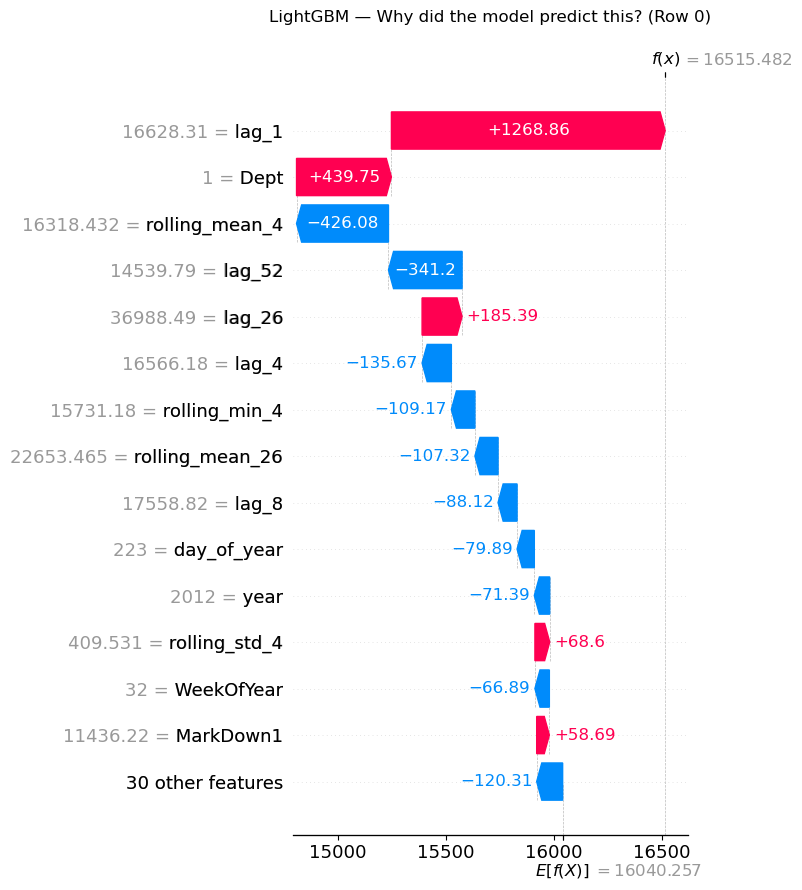

Saved!

This plot shows EXACTLY why the model predicted that number.
Each bar = one feature's contribution to the prediction.


In [10]:
# Explain the very first prediction in the test set
row_to_explain = 0

actual_value    = y_test.iloc[row_to_explain]
predicted_value = tuned_model.predict(X_test.iloc[[row_to_explain]])[0]

print(f"Explaining prediction for row {row_to_explain}:")
print(f"  Actual sales    : ${actual_value:,.2f}")
print(f"  Predicted sales : ${predicted_value:,.2f}")
print()

plot_shap_waterfall(
    explainer, shap_values, X_test,
    row_index=row_to_explain,
    model_name="LightGBM"
)

print("This plot shows EXACTLY why the model predicted that number.")
print("Each bar = one feature's contribution to the prediction.")

Plotting SHAP Dependence for 'lag_52'...


<Figure size 1000x600 with 0 Axes>

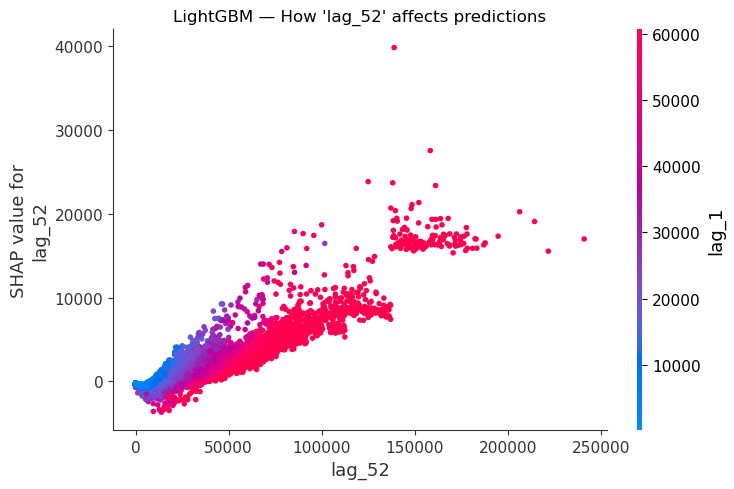

Saved!

X axis = value of lag_52 (sales from same week last year)
Y axis = how much it pushed the prediction up or down
Upward slope = higher last year sales → higher prediction this year


In [11]:
# Plot for lag_52 — usually the most important feature
plot_shap_dependence(
    shap_values, X_test,
    feature_name="lag_52",
    model_name="LightGBM"
)

print("X axis = value of lag_52 (sales from same week last year)")
print("Y axis = how much it pushed the prediction up or down")
print("Upward slope = higher last year sales → higher prediction this year")

In [12]:
print("=" * 55)
print("PHASE 6 COMPLETE!")
print("=" * 55)

print("\nWhat we did:")
print("  1. Loaded Phase 5 LightGBM model")
print("  2. Tuned it with Optuna (50 trials)")
print("  3. Compared before vs after tuning")
print("  4. Explained predictions using SHAP")
print()

print("Files saved:")
print("  models/saved/lightgbm_tuned.pkl")
print("  reports/metrics/best_params.json")
print("  reports/figures/shap_summary_lightgbm.png")
print("  reports/figures/shap_bar_lightgbm.png")
print("  reports/figures/shap_waterfall_lightgbm.png")
print("  reports/figures/shap_dependence_lag_52.png")

print()
print("Best tuned model performance:")
print(f"  RMSE  : {metrics_after['RMSE']:.2f}")
print(f"  MAPE  : {metrics_after['MAPE']:.2f}%")
print(f"  R2    : {metrics_after['R2']:.4f}")
print()
print("Next: Phase 7 — Streamlit Dashboard (show results visually!)")

PHASE 6 COMPLETE!

What we did:
  1. Loaded Phase 5 LightGBM model
  2. Tuned it with Optuna (50 trials)
  3. Compared before vs after tuning
  4. Explained predictions using SHAP

Files saved:
  models/saved/lightgbm_tuned.pkl
  reports/metrics/best_params.json
  reports/figures/shap_summary_lightgbm.png
  reports/figures/shap_bar_lightgbm.png
  reports/figures/shap_waterfall_lightgbm.png
  reports/figures/shap_dependence_lag_52.png

Best tuned model performance:
  RMSE  : 2551.39
  MAPE  : 1489.60%
  R2    : 0.9864

Next: Phase 7 — Streamlit Dashboard (show results visually!)
